In [13]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 400

data = {
    'Age': np.random.randint(29, 77, size=n_samples),
    'Sex': np.random.choice(['M', 'F'], size=n_samples),
    'ChestPainType': np.random.choice(['TA', 'ATA', 'NAP', 'ASY'], size=n_samples),
    'RestingBP': np.random.randint(90, 200, size=n_samples),
    'Cholesterol': np.random.randint(120, 360, size=n_samples),
    'FastingBS': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'MaxHR': np.random.randint(60, 202, size=n_samples),
    'HeartDisease': np.random.choice([0, 1], size=n_samples)
}

df = pd.DataFrame(data)

df.loc[df.sample(frac=0.05).index, 'Cholesterol'] = np.nan
df.loc[df.sample(frac=0.04).index, 'RestingBP'] = 0  # Invalid medical value (0 BP)
df.loc[df.sample(frac=0.03).index, 'Age'] = np.nan
df.to_csv('heart_disease_uncleaned.csv', index=False)

print("Uncleaned dataset 'heart_disease_uncleaned.csv' created successfully!")
print("Missing values per column:")
print(df.isnull().sum())
print("\n--- Dataset Summary ---")
print(df.info())

Uncleaned dataset 'heart_disease_uncleaned.csv' created successfully!
Missing values per column:
Age              12
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol      20
FastingBS         0
MaxHR             0
HeartDisease      0
dtype: int64

--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            388 non-null    float64
 1   Sex            400 non-null    object 
 2   ChestPainType  400 non-null    object 
 3   RestingBP      400 non-null    int64  
 4   Cholesterol    380 non-null    float64
 5   FastingBS      400 non-null    int64  
 6   MaxHR          400 non-null    int64  
 7   HeartDisease   400 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 25.1+ KB
None


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-defining the dataset (to fix the NameError)
np.random.seed(42)
n_samples = 400
data = {
    'Age': np.random.randint(29, 77, size=n_samples),
    'Sex': np.random.choice(['M', 'F'], size=n_samples),
    'ChestPainType': np.random.choice(['TA', 'ATA', 'NAP', 'ASY'], size=n_samples),
    'RestingBP': np.random.randint(90, 200, size=n_samples),
    'Cholesterol': np.random.randint(120, 360, size=n_samples),
    'FastingBS': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
    'MaxHR': np.random.randint(60, 202, size=n_samples),
    'HeartDisease': np.random.choice([0, 1], size=n_samples)
}
df = pd.DataFrame(data)

# Injecting the messy data again for the cleaning task
df.loc[df.sample(frac=0.05).index, 'Cholesterol'] = np.nan
df.loc[df.sample(frac=0.04).index, 'RestingBP'] = 0
df.loc[df.sample(frac=0.03).index, 'Age'] = np.nan

# --- STEP 2: DATA CLEANING PHASE (The part that had the error) ---
# Fixing Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fixing Cholesterol
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].mean())

# Fixing RestingBP (replacing 0 with median)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())

print("Cleaning Complete! Missing values:")
print(df.isnull().sum())

Cleaning Complete! Missing values:
Age              0
Sex              0
ChestPainType    0
RestingBP        0
Cholesterol      0
FastingBS        0
MaxHR            0
HeartDisease     0
dtype: int64


/tmp/ipykernel_879/2021329054.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, ax=axes[0, 1], palette='pastel')
/tmp/ipykernel_879/2021329054.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='Age', data=df, ax=axes[1, 0], palette='Set2')


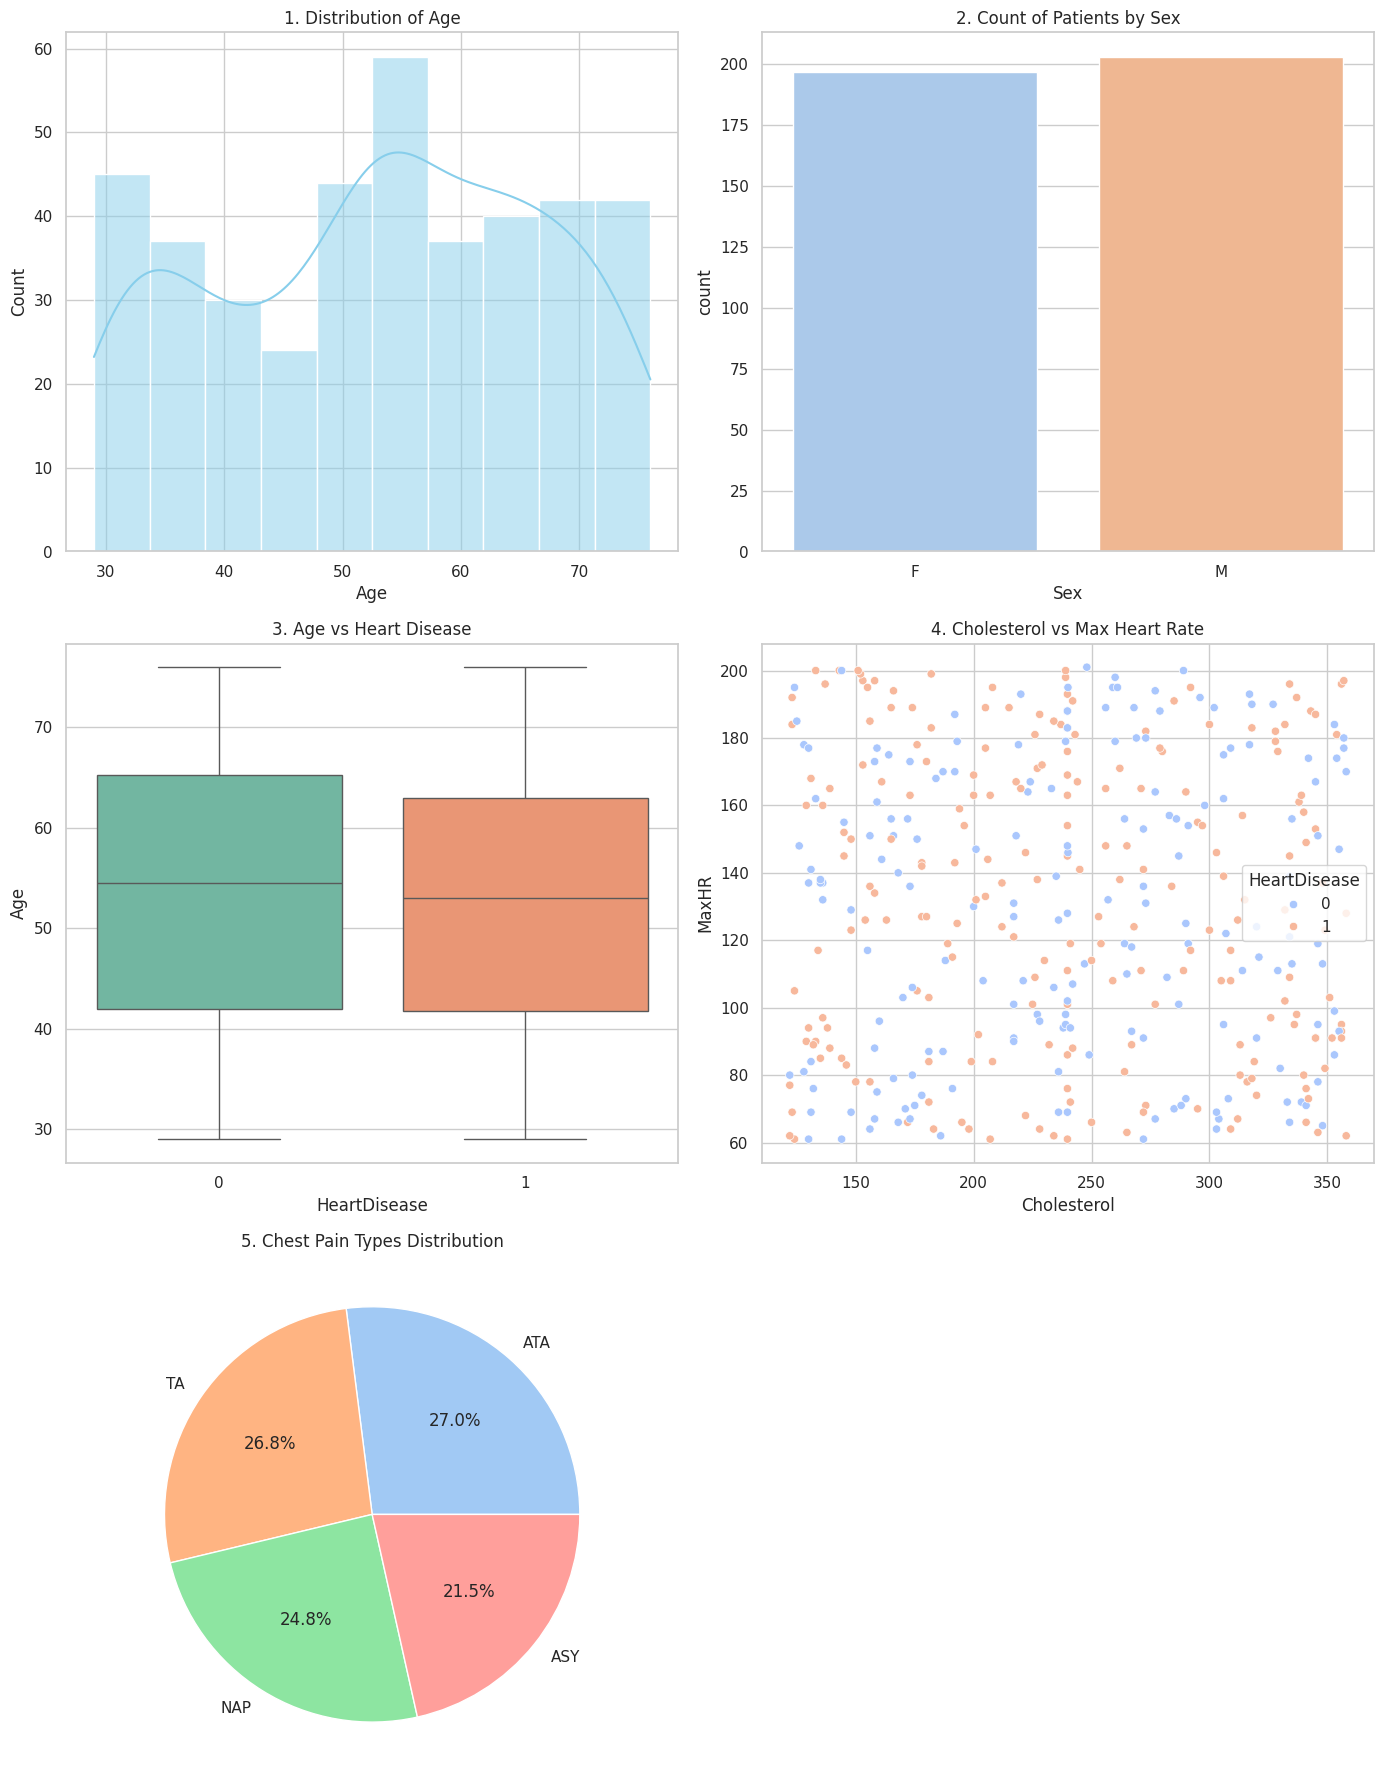

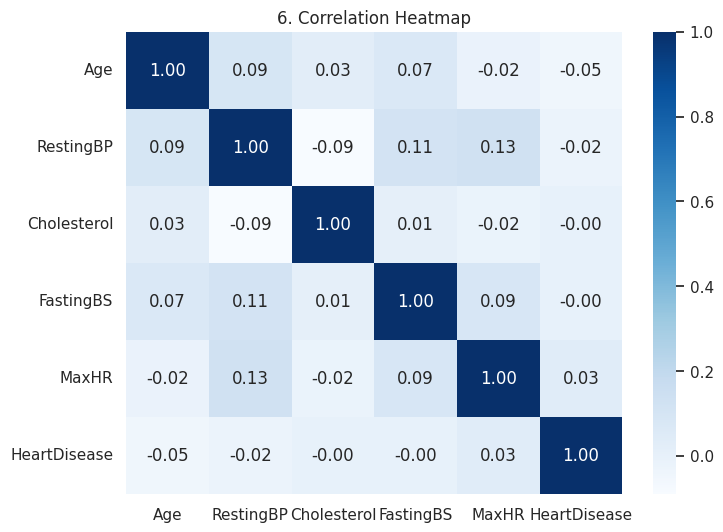

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Distribution of Age')

sns.countplot(x='Sex', data=df, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('2. Count of Patients by Sex')

sns.boxplot(x='HeartDisease', y='Age', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Age vs Heart Disease')

sns.scatterplot(x='Cholesterol', y='MaxHR', hue='HeartDisease', data=df, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('4. Cholesterol vs Max Heart Rate')

chest_pain_counts = df['ChestPainType'].value_counts()
axes[2, 0].pie(chest_pain_counts, labels=chest_pain_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[2, 0].set_title('5. Chest Pain Types Distribution')

axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('6. Correlation Heatmap')
plt.show()

In [14]:
df['Age_BP_Risk'] = df['Age'] * df['RestingBP']

print("1. New Feature 'Age_BP_Risk' created successfully!")
print(df[['Age', 'RestingBP', 'Age_BP_Risk']].head())

df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df = pd.get_dummies(df, columns=['ChestPainType'], drop_first=True)
correlations = df.corr()['HeartDisease'].abs().sort_values(ascending=False)

print("\n2. Correlation of features with HeartDisease (Target):")
print(correlations)

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

print("\n3. Feature Selection Complete!")
print(f"Total features selected for training: {X.shape[1]}")
print("Features list:", list(X.columns))

1. New Feature 'Age_BP_Risk' created successfully!
    Age  RestingBP  Age_BP_Risk
0  67.0        181      12127.0
1  57.0        164       9348.0
2  43.0         93       3999.0
3  71.0        168      11928.0
4  36.0         95       3420.0

2. Correlation of features with HeartDisease (Target):
HeartDisease         1.000000
ChestPainType_NAP    0.133201
Age_BP_Risk          0.091112
RestingBP            0.058623
ChestPainType_ATA    0.052877
ChestPainType_TA     0.047820
Age                  0.045744
Sex                  0.036320
MaxHR                0.034140
Cholesterol          0.004235
FastingBS            0.001360
Name: HeartDisease, dtype: float64

3. Feature Selection Complete!
Total features selected for training: 10
Features list: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Age_BP_Risk', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA']


In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import pickle

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(random_state=42)
dt_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)

log_reg.fit(X_train_scaled, y_train)
dt_clf.fit(X_train_scaled, y_train)
rf_clf.fit(X_train_scaled, y_train)

print("--- Baseline Models Performance ---")
for name, model in [("Logistic Regression", log_reg), ("Decision Tree", dt_clf), ("Random Forest", rf_clf)]:
    preds = model.predict(X_test_scaled)
    print(f"\n{name}:")
    print(f"Precision: {precision_score(y_test, preds):.2f}")
    print(f"Recall: {recall_score(y_test, preds):.2f}")


print("\n--- Tuning Random Forest using GridSearchCV ---")
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters found:", grid_search.best_params_)

final_preds = best_model.predict(X_test_scaled)
print("\n--- Final Model Evaluation Report ---")
print(classification_report(y_test, final_preds))


with open('best_heart_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("\nSuccess! Best model 'best_heart_model.pkl' and scaler 'scaler.pkl' are saved and ready for deployment.")

--- Baseline Models Performance ---

Logistic Regression:
Precision: 0.60
Recall: 0.73

Decision Tree:
Precision: 0.68
Recall: 0.59

Random Forest:
Precision: 0.60
Recall: 0.61

--- Tuning Random Forest using GridSearchCV ---
Best Parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}

--- Final Model Evaluation Report ---
              precision    recall  f1-score   support

           0       0.41      0.37      0.39        30
           1       0.60      0.64      0.62        44

    accuracy                           0.53        74
   macro avg       0.50      0.50      0.50        74
weighted avg       0.52      0.53      0.52        74


Success! Best model 'best_heart_model.pkl' and scaler 'scaler.pkl' are saved and ready for deployment.
